# <span style = "color:blue"><center> AUTOMATED COTTON PLANT DISEASE CLASSIFICATION </center></span>

***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

from sklearn.utils import shuffle
from skimage.transform import resize
import glob
from sklearn.model_selection import train_test_split

In [2]:
Aphids = glob.glob('Cotton plant disease/Aphids edited/*.jpg')
Army_worm = glob.glob('Cotton plant disease/Army worm edited/*.jpg')
Bacterial_Blight = glob.glob('Cotton plant disease/Bacterial Blight edited/*.jpg')
Healthy_leaf = glob.glob('Cotton plant disease/Healthy leaf edited/*.jpg')
Powdery_Mildew = glob.glob('Cotton plant disease/Powdery Mildew Edited/*.jpg')
Target_spot = glob.glob('Cotton plant disease/Target spot edited/*.jpg')

In [3]:
print('Length of Aphids : ', len(Aphids))
print('Length of Army worm : ', len(Army_worm))
print('Length of  Bacterial Blight : ' , len(Bacterial_Blight))
print('Length of  Healthy leaf : ', len(Healthy_leaf))
print('Length of  Powdery Mildew : ', len(Powdery_Mildew))
print('Length of Target spot : ' , len(Target_spot))

Length of Aphids :  36
Length of Army worm :  40
Length of  Bacterial Blight :  39
Length of  Healthy leaf :  38
Length of  Powdery Mildew :  38
Length of Target spot :  38


In [4]:
images = []
labels = []

for i in Aphids:
    img = plt.imread(i)
    images.append(img)
    labels.append(0)

for i in Army_worm:
    img = plt.imread(i)
    images.append(img)
    labels.append(1)

for i in Bacterial_Blight:
    img = plt.imread(i)
    images.append(img)
    labels.append(2)

for i in Healthy_leaf:
    img = plt.imread(i)
    images.append(img)
    labels.append(3)

for i in Powdery_Mildew:
    img = plt.imread(i)
    images.append(img)
    labels.append(4)

for i in Target_spot:
    img = plt.imread(i)
    images.append(img)
    labels.append(5)

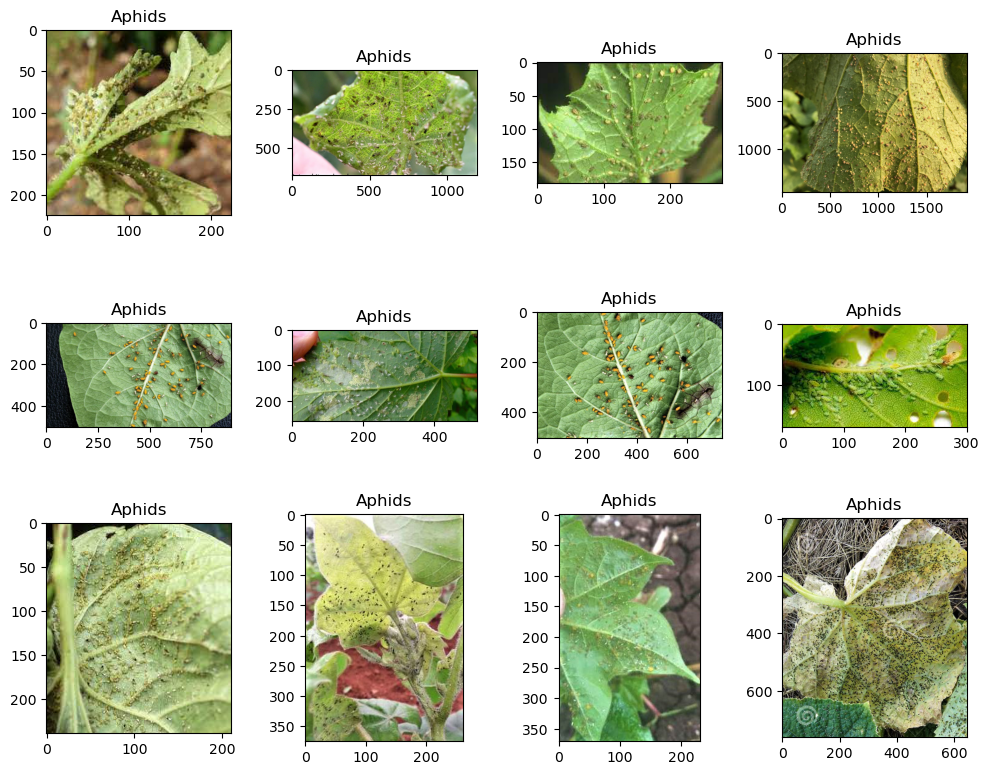

In [5]:
classes = {0:'Aphids' , 1: 'Army worm' , 2:'Bacterial blight' , 3 : 'Healthy leaf' , 4 : 'Powdery Mildew' , 5 : 'Target_spot' }

plt.figure(figsize=(10, 8))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    plt.title(classes[labels[i]])
plt.tight_layout()

In [6]:
images,labels = shuffle(images , labels , random_state = 12)#shuffle in same format

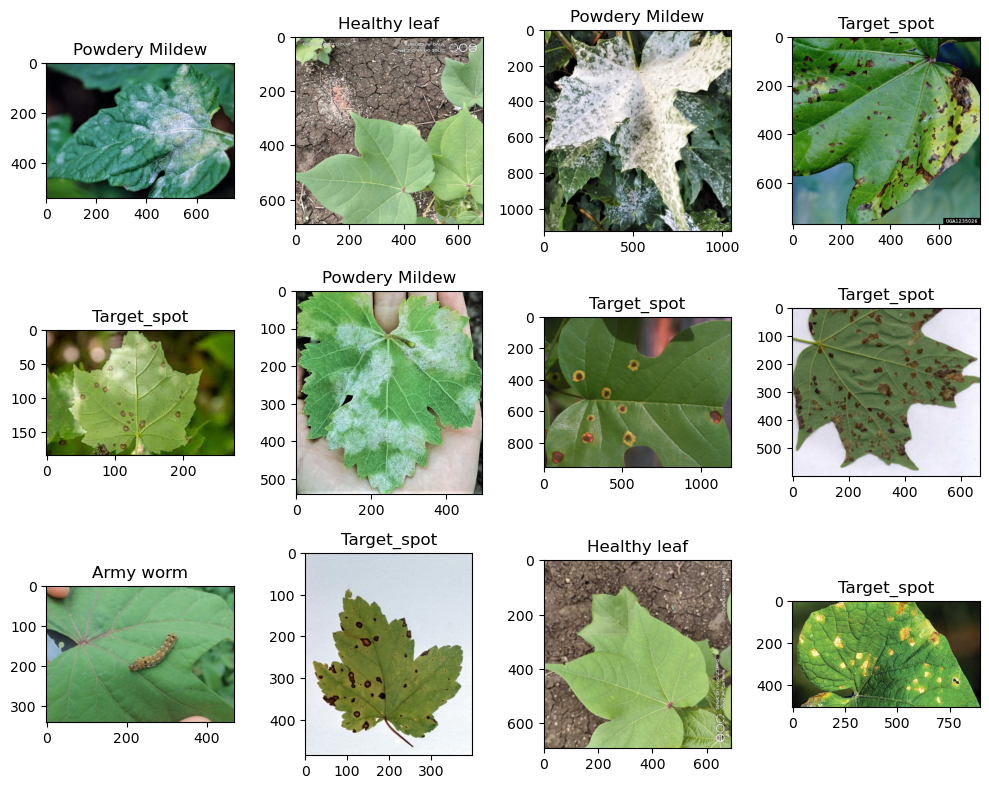

In [7]:
plt.figure(figsize=(10, 8))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    plt.title(classes[labels[i]])
plt.tight_layout()

In [8]:
X = []

for i in images:
    X.append(resize(i, (224,224)))

In [9]:
X = np.array(X)
y = np.array(labels)

In [10]:
print(X.shape , y.shape)

(229, 224, 224, 3) (229,)


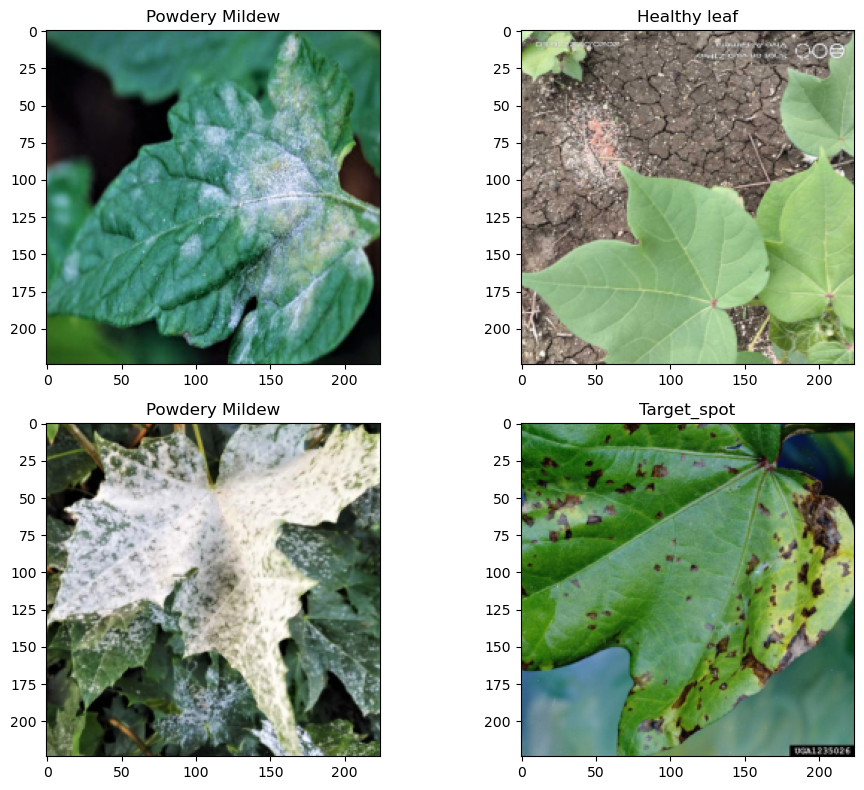

In [11]:
plt.figure(figsize=(10, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(X[i])
    plt.title(classes[labels[i]])
plt.tight_layout()

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 ,stratify = y , random_state = 12)

In [13]:
print(len(X_train) , len(y_train))
print(len(X_test) , len(y_test))

183 183
46 46


In [14]:
from tensorflow.keras.applications.efficientnet import preprocess_input

X_train = preprocess_input(X_train)
X_test   = preprocess_input(X_test)

In [15]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomContrast(0.2),
]) # artificially increases your dataset.

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

num_of_classes =  6 
# Pretrained model (feature extractor)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


base_model.trainable = True #Unfreezes the whole pretrained model (all layers can learn)

for layer in base_model.layers[:-30]: #last 10 layers not included
    layer.trainable = False #Freeze the most layers

# Final model
model = Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    base_model,   # not trained
    layers.GlobalAveragePooling2D(),#  reduces parameters (faster + less overfitting) ,EfficientNet outputs feature maps, not flat vectors.
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_of_classes, activation='softmax')
])

In [29]:
model.compile(
    optimizer= keras.optimizers.Adam(learning_rate=1e-4), #Small learning rate (e.g. 1e-4) → weights change slowly & carefully
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │          40,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,090,761 (15.61 MB)

 Trainable params: 1,537,350 (5.86 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

In [31]:
model.fit(X_train , y_train , epochs = 15 , validation_split = 0.2)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.1507 - loss: 1.8453 - val_accuracy: 0.1351 - val_loss: 1.8041
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2123 - loss: 1.8200 - val_accuracy: 0.1351 - val_loss: 1.8070
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1644 - loss: 1.8579 - val_accuracy: 0.1351 - val_loss: 1.8099
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1849 - loss: 1.8277 - val_accuracy: 0.1351 - val_loss: 1.8099
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1712 - loss: 1.8416 - val_accuracy: 0.1351 - val_loss: 1.8095
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2329 - loss: 1.7913 - val_accuracy: 0.1351 - val_loss: 1.8086
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2260 - loss: 1.7718 - val_accuracy: 0.1351 - val_loss: 1.8079
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1918 - loss: 1.8327 - val_accuracy: 0.1351 - val_loss: 1.8068
Epoch 9/15
5/5 

In [32]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step


In [33]:
y_pred = [np.argmax(i) for i in y_pred]

In [34]:
model.evaluate(X_train , y_train)

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 680ms/step - accuracy: 0.1694 - loss: 1.8049


[1.8048510551452637, 0.16939890384674072]

### Model Evaluation

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Accuracy score

In [36]:
accuracy_score(y_test,y_pred)

0.15217391304347827

#### Confusion Matrix

<Axes: >

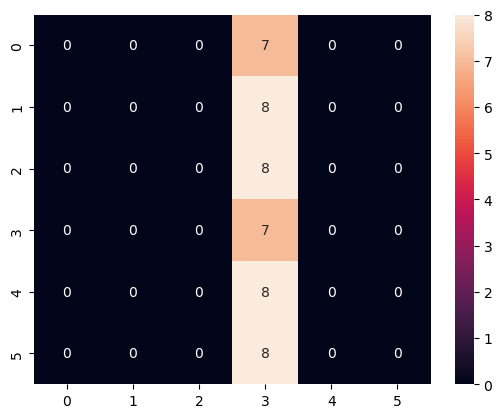

In [37]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot = True, fmt = 'd')

#### Classification Report

In [38]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         8
           3       0.15      1.00      0.26         7
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00         8

    accuracy                           0.15        46
   macro avg       0.03      0.17      0.04        46
weighted avg       0.02      0.15      0.04        46



C:\Users\Asharaf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Asharaf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Asharaf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


***